Introduction: Briefly state that this dataset covers e-commerce fraud.

Data Cleaning: Document your steps (e.g., dropping nulls, converting dates).

Geolocation: Explain that ip_address is mapped to country using IpAddress_to_Country.csv.

Matplotlib is building the font cache; this may take a moment.


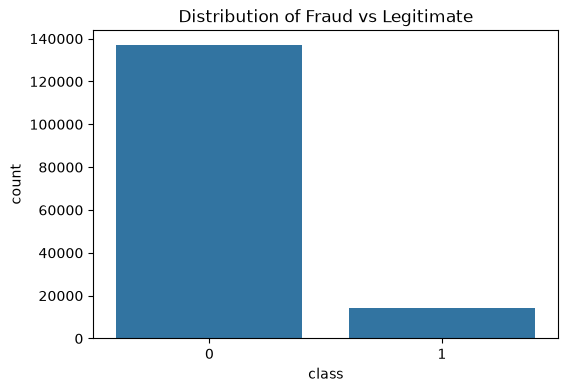

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
df_ip = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Clean
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])
df_fraud.drop_duplicates(inplace=True)

# Geolocation Mapping
df_fraud = df_fraud.sort_values('ip_address')
df_ip = df_ip.sort_values('lower_bound_ip_address')
df_merged = pd.merge_asof(df_fraud, df_ip, left_on='ip_address', right_on='lower_bound_ip_address')

# Visualize Imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df_merged)
plt.title('Distribution of Fraud vs Legitimate')
plt.show()

In [2]:
# Save the cleaned and merged data so the next notebook can use it
df_merged.to_csv('../data/processed/cleaned_fraud_data.csv', index=False)